## Project Rationale
+ unlabeled image or imaging data are plenty
+ predefined measurements or statistics introduce human bias, could possibly miss subtle patterns.
+ some phenotypes are too complicated to describe, (for example, describing shapes with Kendall shape space), we want something more flexible, easy and also can be generalized to other data types.

In summary, we want to extract descriptors/endophenotypes from image or imaging data without human supervision. This notebook will go through the workflow of extracting endophenotypes from brain MRI imaging data.

## Request UK Biobank data
This is just for reference, you need to be a delegate of the project to request for new data.

See [here](https://www.youtube.com/watch?v=W6gECdiA538)

## Download UK Biobank data

See [here](https://biobank.ctsu.ox.ac.uk/~bbdatan/Data_Access_Guide.pdf) for reference.

1. log into https://ams.ukbiobank.ac.uk/<br>
go to Projects -> View/Update -> Data tab<br>
go to showcase to refresh or download data<br>
click the basket id<br>
type in the MD5 from ukbiobank notification email<br>
fetch the enc file.<br>
2. upload the key (attached in the notification email) and the enc file to the server<br>
download ukbunpack from data showcase-> downloads->7 file handlers), or use `wget  -nd biobank.ndph.ox.ac.uk/ukb/util/ukbunpack`<br>
`chmod +x ukbunpack`<br>
3. `./ukbunpack enc_key`, this will generate a .enc_ukb file<br>
download ukbconv from data showcase -> downloads -> 7 file handlers, or use `wget  -nd  biobank.ndph.ox.ac.uk/ukb/util/ukbconv`, `chmod + x ukbconv`<br>
type ./ukbconv for help information<br>
4. if downloading bulk data, then `./ukbconv enc_ukb bulk -s(field_id)`<br>
for example: ./ukbconv enc_ukb bulk -s20210, it would output a .fields file and a .bulk file.<br>
fields file records all fields in this basket, bulk file records all samples in this bulk field.<br>
download ukbfetch again from the data showcase then change the permission. <br>
`wget  -nd  biobank.ndph.ox.ac.uk/ukb/util/ukbfetch`<br>
5. create a new folder, copy key file, bulk file and `/data484_1/zxie3/ukb_data_tmp/download.py` into this new folder, modify download.py to include the correct key file, then in a new [screen](https://www.geeksforgeeks.org/screen-command-in-linux-with-examples/), do `/data4012/zxie3/anaconda3/bin/python download.py -k key_file -b bulk_file`


## Input processing

The processing of the brain MRI is done by UK Biobank and is detailed in the [Brain Imaging Document](https://biobank.ctsu.ox.ac.uk/crystal/crystal/docs/brain_mri.pdf). Currently we have downloaded T1, T2-FLAIR and diffusion MRI imaging data from the UK Biobank.

T1: `/data5/kpatel38/MRI/T1_New/T1_extracted`<br>
T2: `/data5/kpatel38/MRI/T2_New/T2_extracted`<br>
DTI (Fractional Anisotropy): `/data4012/kpatel38/dMRI/linear_registered_mri`<br>
DTI (raw): `/data4012/zxie3/UKBB/DTI`<br>
All phenotypes: `/data5/Ziqian/UKBB/UKB_data/UKB_all.csv`<br>
TODO: break this huge `UKB_all.csv` into separate files for the ease of read and update. 

The first three paths contain processed input, the data of each subject is inside a separate folder. Here is an example of the T1 data:

In [7]:
!ls /data5/kpatel38/MRI/T1_New/T1_extracted/3499830_20252_2_0/T1

T1_brain_to_MNI.nii.gz	  T1_unbiased_brain_linear.nii.gz
T1_fast			  modulated_MNI.nii.gz
T1_first		  smooth_3_modulated_MNI.nii.gz
T1_unbiased_brain.nii.gz  transforms


The format of the name of the folder is (subject id)\_(UK Biobank data field)\_(data collection instance)\_(file index).
3499830 is the subject id, [20252](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=20252) is the data field for T1, 2 means the data is collected between 2014~2019 (detailed in the `2 instances` tab in the ukbiobank data showcase), 0 means it is the first imaging file of this subject in this visit. Most of the files in this folder are processed by UK Biobank, which are described in the brain imaging document provided above. These 3 files are later generated: `T1_unbiased_brain_linear.nii.gz`, `modulated_MNI.nii.gz`, `smooth_3_modulated_MNI.nii.gz`.

`T1_unbiased_brain_linear.nii.gz`: This is subject's processed brain MRI linearly registered to the MNI-152 template using the linear transformation matrix in the `transforms` folder, example command line using FSL: `flirt -in brain_extracted_brain.nii.gz -ref standard.nii.gz -out brain_linear -omat linear_transform.mat`.<br>
`modulated_MNI.nii.gz`: This is Jacobian modulated image, generated by multiplying the imaging data by the Jacobian determinant of the transformation. The Jacobian determinant can be generated by `fnirt` in the FSL, the multiplication is done using `fslmaths`.<br>
`smooth_3_modulated_MNI.nii.gz`: This is Jacobian modualted image further smoothed by 3x3x3 Gaussian kernel using `fslmaths`.

## Model training

An example training scripts are at `/data/whe4/DeepENDO/AE_training_2023_2_gpus/small_lr/training_128` on server 122.
The dependencies are listed at the github repo [here](https://github.com/ZhiGroup/DeepENDO). Usually, the learning rate for the training is tuned using pytorch lightning's [learning rate finder](https://lightning.ai/docs/pytorch/stable/api/lightning.pytorch.callbacks.LearningRateFinder.html)<br>
The script is at `/data/whe4/DeepENDO/AE_training_2023_2_gpus/small_lr/lr_finder/driver.ipynb`.<br>
We split the dataset into train, validation and test already:<br>
The list of training data is at `/data/whe4/DeepENDO/AE_training_2023_2_gpus/small_lr/training_128/train_mixed_ethnicity.csv`<br>
The list of validation data at `/data/whe4/DeepENDO/AE_training_2023_2_gpus/small_lr/training_128/val_mixed_ethnicity.csv`<br>
The list of test/GWAS data at
`/data/whe4/DeepENDO/AE_training_2023_2_gpus/small_lr/training_128/test_model/T1_128_gwas.csv`

## Endophenotypes

After training, the endophenotypes of this model are stored at `/data/whe4/DeepENDO/AE_interpretation_2023_2_gpus/small_lr/T1_128_interpretation/T1_128_endo.pkl`, which is a list of numpy array, other times it can also be a pickled dictionary with file names as keys and 128-dimensional numpy arrays as values.

## Interpretation

We want to interpret the endophenotypes, see what they represents. We simply use the perturbation approach: adding some noise to each dimension of the representation and looking at the reconstruction difference, then average over many subjects. The code is at [here](https://github.com/ZhiGroup/DeepENDO/blob/main/interpretation/perturbation%20based%20approach.ipynb), note that this implementation is not memory efficient, only mean and standard deviation need to be updated and saved instead of all the samples.

## Descriptive analysis

First we want to look at the distribution of endophenotypes at each dimension. Here is the sample code:

In [1]:
import pickle as pkl, numpy as np


features = pkl.load(open("/data/whe4/DeepENDO/AE_interpretation_2023_2_gpus/small_lr/T1_128_interpretation/T1_128_endo.pkl", 'rb'))
features = np.vstack(features)

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns, warnings
warnings.filterwarnings('ignore')

# 128 = 16 * 8 so we create a 16 x 8 grid. 
# "features" is an array of shape n x 128 where n is the number of subjects, storing the endophenotypes of all subjects.
fig, axs = plt.subplots(16, 8, figsize=(80, 160))
for i in range(axs.shape[0]):
    for j in range(axs.shape[1]):
        idx = i * 8 + j
        sns.kdeplot(features[:, idx], ax=axs[i, j], fill=True)
        # axs[i, j].hist(pheno[:, idx], 200)
        axs[i, j].axis('off')
        axs[i, j].text(0, 1, idx, fontsize=80, transform=axs[i, j].transAxes)
fig.tight_layout()

We also generate the correlation heatmap to make sure there is no feature collapsing.

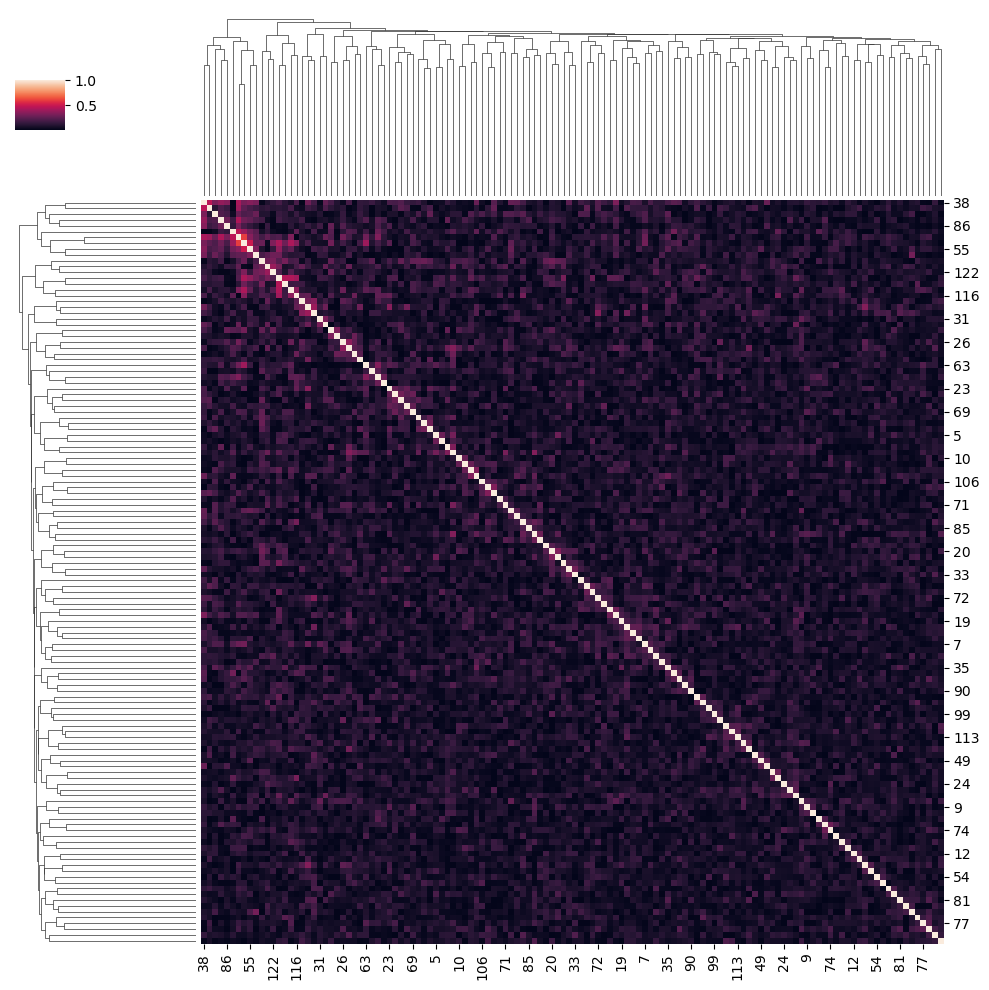

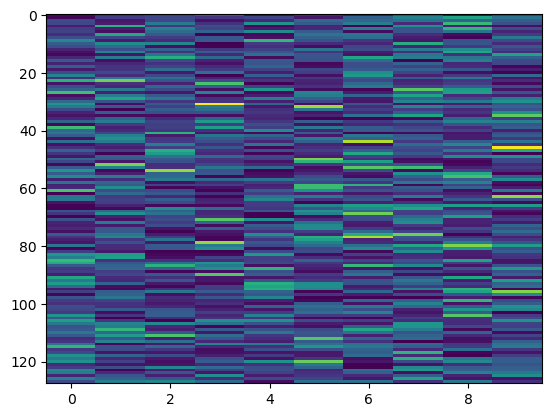

In [18]:
abscorr = np.abs(np.corrcoef(features.T))
dendro = sns.clustermap(abscorr)
# reorder the endophenotypes based on there correlation, group similar endophenotypes together
idx = dendro.dendrogram_row.reordered_ind
# TODO: choose some good looking color map
plt.imshow(abscorr[idx][:, idx])
# TODO: add additional formatting such as xlabel and ylabel.
plt.show()

# additionally we can compute correlation with some known phenotypes from the same subjects "phenos", of shape n x k, 
# where k is the number of known phenotypes, like age, sex, disease status, etc.
# all requested phenotypes are at /data5/Ziqian/UKBB/UKB_data/UKB_all.csv
pheno = np.random.randn(features.shape[0], 10)
corr = np.abs(np.corrcoef(np.hstack([features, pheno]).T))
inter_corr = corr[:features.shape[1], features.shape[1]:]
plt.imshow(inter_corr[idx], aspect='auto', interpolation='nearest')

We can also visualize the embedding using UMAP or TSNE to see if there is any clustering structure or outliers:

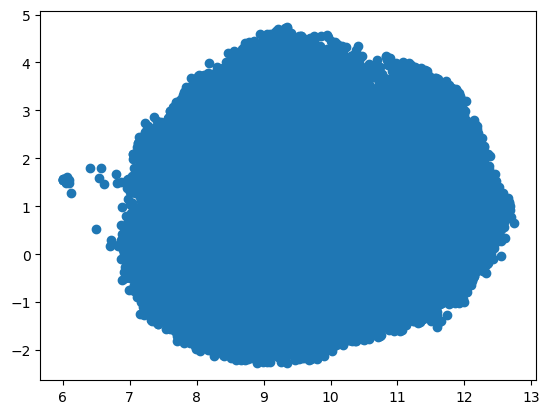

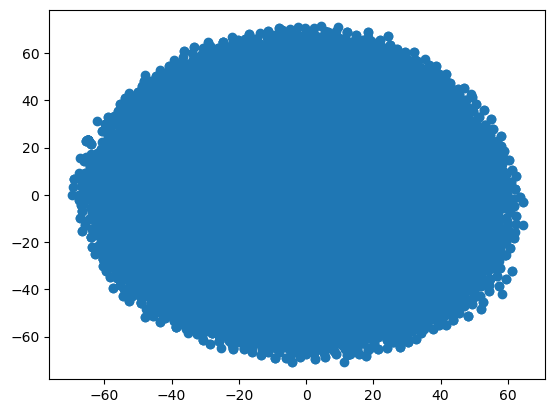

In [27]:
import umap
from sklearn.manifold import TSNE


embedding2d_umap = umap.UMAP().fit_transform(features)
plt.scatter(embedding2d_umap[:, 0], embedding2d_umap[:, 1])
plt.show()
embedding2d_tsne = TSNE(n_components=2, learning_rate='auto', init='random').fit_transform(features)
plt.scatter(embedding2d_tsne[:, 0], embedding2d_tsne[:, 1])
plt.show()

## Genome wide association study

We have used 3 tools to perform GWAS:
1. BOLT-LMM
2. GCTA: fastGWA
3. torchGWAS

GWAS typically requires 3 files: genotype file, phenotype file and covariate file. Covariate file include variables such as sex, age, ethnicity, genetic principal components and other study depedent confounders.

### GWAS using BOLT-LMM

BOLT-LMM is deprecated, it is included here for backward compatibility.<br>
It took UK Biobank genotype data in [plink bed format](https://www.cog-genomics.org/plink/1.9/formats#bed) as input, the data is at `/data5/jshi3/ukb/data/ukb_hap_merged.bed`<br>
The first step is to extract the subset of data containing only the subjects in the study.<br>
The command to use is `/data5/Ziqian/plink --bfile /data5/jshi3/ukb/data/ukb_hap_merged --make-bed --keep {phenotype_file} --out {output_file}`<br>
The extracted bed files are at `/data4012/zxie3/MRI_AE_small_training_set_GWAS/ukb_hap_chrall_T1.bed` and `/data4012/zxie3/MRI_AE_small_training_set_GWAS/ukb_hap_chrall_T1.bed`, for T1 and T2 respectively, the same folder also contains the accompanying [bim](https://www.cog-genomics.org/plink/1.9/formats#bim) and [fam](https://www.cog-genomics.org/plink/1.9/formats#fam) file.<br>
In our early work, we used [sex](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=31), [genetic ethnicity grouping](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=22006), [first 10 genetic PC](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=22009), [ethnicity](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=21000), [age](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=21003), [T1 inverted contrast to noise ratio](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=25735), [assessment center](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=54), [Discrepancy between T2 FLAIR brain image and T1 brain image](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=25736) as covariates. T1 inverted contrast to noise ratio is a QC measure only for T1 and Discrepancy between T2 FLAIR brain image and T1 brain image is a QC measure only for T2. We partitioned the test data into a 2:1 split, 2 for GWAS discovery and 1 for replication. The covariate file for T1 is at `/data4012/zxie3/MRI_AE_small_training_set_GWAS/T1_covar_discovery`. You can replace "T1" with "T2", "discovery" with "replication" to get all 4 covariate files.<br>
The phenotype file for T1 is at `/data4012/zxie3/MRI_AE_small_training_set_GWAS/T1_pheno_discovery`. Again you can do the same replacement of the file name to get all files.<br>
The example command line to run BOLT-LMM is `BOLT-LMM_v2.3.6/bolt --numThreads 48 --bfile ../T1T2_GWAS/ukb_hap_chrall_T1 --phenoFile T1_pheno_discovery --phenoCol QT$i --covarFile T1_covar_discovery --covarCol SEX --covarCol GE --covarCol ETH --covarMaxLevels 22 --qCovarCol AGE --qCovarCol PC{0:9} --qCovarCol 25735 --covarCol 54 --statsFile stat_T1_$i'_discovery' --LDscoresFile ../BOLT-LMM_v2.3.6/tables/LDSCORE.1000G_EUR.tab.gz --lmmInfOnly --LDscoresMatchBp 2>&1|tee out_T1_$i'_discovery'`<br>
BOLT-LMM compiles with mkl so it runs fast on the intel CPU. This command was run on server 23 and Dr. Han Chen's server (129.106.2.222).

### GWAS using GCTA fastGWA
#### Genotype file processing
We then switched from BOLT-LMM to fastGWA, which is much faster. Instead of using the array genotype data, we used the imputed genotype data, which has a marker size more than 10 times larger in the [bgen](https://biobank.ndph.ox.ac.uk/ukb/ukb/docs/bgen12formats.pdf) format, the original bgen files are at `/data6/ukbiobank/genotype_data/bgen_files_august2020/*.bgen`.<br>
Similar to the way we processed the bed file, we used several tools to first extract and then merge a subset of the genotype data: [bgenix](https://enkre.net/cgi-bin/code/bgen/doc/trunk/doc/wiki/bgenix.md) at `/data4012/zxie3/gcta/bin/bgenix` was used to create an index for each bgen file, [qctool](https://www.chg.ox.ac.uk/~gav/qctool_v2/) at `/data4012/zxie3/gcta/qctool_v2/qctool` was used for extracting a subset of genotype data with a smaller sample size and a smaller marker size, [cat-bgen](https://enkre.net/cgi-bin/code/bgen/doc/trunk/doc/wiki/cat-bgen.md) at `/data4012/zxie3/gcta/bin/cat-bgen` was used to merge the individual chromosome bgen files together.<br>
Here is a sample script for processing the bgen files:
```Python
from glob import glob
from multiprocessing import Pool
import os, pandas as pd
# TODO: change os.system to subprocess


qctool_path = "/data4012/zxie3/gcta/qctool_v2/qctool"
bgens = glob("/data6/ukbiobank/genotype_data/bgen_files_august2020/*.bgen")
sample = "/data6/ukbiobank/genotype_data/bgen_files_august2020/ukb24247_imp_chr1_v3_s487296.sample"

def proc(x):
    c = x.split("_")[-2]
    s = f"-g {x} -s {sample}"
    cmd = f"nohup {qctool_path} {s} -incl-samples /data4012/zxie3/gcta/MRI_AE_samples.txt -og /data/zxie3/ukb_MRI_bgen/MRI_samples_{c}.bgen -os /data/zxie3/ukb_MRI_bgen/MRI_samples_{c}.sample > {c}.out"  # see below for the generation of this sample file.
    os.system(cmd)

with Pool(len(bgens)) as p:  # multiprocessing may not help because it is I/O bound
    p.map(proc, bgens)  # get only the subjects included in our study

bgenix_path = "/data4012/zxie3/gcta/bin/bgenix"
bgens_subset = glob("/data4012/zxie3/ukb_MRI_bgen/*.bgen")
cmd = f"{bgenix_path} -g {bgens_subset[0]} -index"
os.system(cmd)  # create index using bgenix

snp_list = pd.read_table("/data5/bguo1/DNAnexus_T1_pheno_discovery_20230102_QT0_GWAS.txt.gz", compression="gzip")
snp_list.SNP.to_csv("incl_rsid", index=False)  # here we take Baihong Guo's SNP list, he applied a MAF filter of 0.0001 and a missing rate filter of 0.05.
bgens = glob("/data/zxie3/ukb_MRI_bgen/*chr*.bgen")

def filter_snp(x):
    x_name = x.split('/')[-1].split('.')[0]
    os.system(f"{qctool_path} -g {x} -og /data/zxie3/ukb_MRI_bgen/{x_name}_filtered.bgen -incl-rsids incl_rsid")

with Pool(len(bgens)) as p:
    p.map(filter_snp, bgens)

# in the last step we merge the bgen files into one:
# ./cat-bgen -g /data/zxie3/ukb_MRI_bgen/*_filtered.bgen -og /data/zxie3/ukb_MRI_bgen/all_filtered.bgen
# we also use bgenix -g all_filtered.bgen -list > varid_list to generate a variant id list
```
#### Subject exclusion criteria
We made several changes to both the samples and the covariates in this GWAS run:
1. Subjects with a sex mismatch, where the self-reported sex differs from the [genetic sex](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=22001), were excluded.
2. Subjects who withdrawed their consents were excluded. To download the withdraw list (you need to be assigned as a delegate to do this), login to the [AMS](https://ams.ukbiobank.ac.uk/), go to Projects -> View/Update -> Data -> go to Showcase to refresh or download data -> n Withdrawals -> Download withdrawals. 
3. Subjects in the replication chort who have relatives in the discovery cohort are excluded. The kinship coefficient threshold is 0.5**4.5.

The processing script is provided here for reference:

```Python
import pandas as pd
from dask import dataframe as dd

T1_pheno = pd.read_table("/data4012/zxie3/MRI_AE_small_training_set_GWAS/T1_pheno_discovery", sep=' ')
T2_pheno = pd.read_table("/data4012/zxie3/MRI_AE_small_training_set_GWAS/T2_pheno_discovery", sep=' ')
T1_covar = pd.read_table("/data4012/zxie3/MRI_AE_small_training_set_GWAS/T1_covar_discovery", sep=' ')
T2_covar = pd.read_table("/data4012/zxie3/MRI_AE_small_training_set_GWAS/T2_covar_discovery", sep=' ')
T1_pheno_r = pd.read_table("/data4012/zxie3/MRI_AE_small_training_set_GWAS/T1_pheno_replication", sep=' ')
T2_pheno_r = pd.read_table("/data4012/zxie3/MRI_AE_small_training_set_GWAS/T2_pheno_replication", sep=' ')
T1_covar_r = pd.read_table("/data4012/zxie3/MRI_AE_small_training_set_GWAS/T1_covar_replication", sep=' ')
T2_covar_r = pd.read_table("/data4012/zxie3/MRI_AE_small_training_set_GWAS/T2_covar_replication", sep=' ')
withdrawal = pd.read_table("/data4012/zxie3/gcta/withdraw24247_281_20230821.txt", header=None)  # withdrawal list
discovery_iid = (set(T1_pheno.IID).intersection(T1_covar.IID)).union(set(T2_pheno.IID).intersection(T2_covar.IID)).difference(withdrawal[0])
replication_iid = (set(T1_pheno_r.IID).intersection(T1_covar_r.IID)).union(set(T2_pheno_r.IID).intersection(T2_covar_r.IID)).difference(withdrawal[0])
kinship = pd.read_table('/data5/ardalan/ukbiobank_june_2018/ukb24247_rel_s488346.dat', sep=' ')[['ID1', 'ID2', 'Kinship']]
kinship = kinship[kinship.Kinship != -1]
replication_exclusion = []
for id1, id2, _ in kinship.values:
    if id1 in discovery_iid and id2 in replication_iid:
        replication_exclusion.append(id2)
    elif id1 in replication_iid and id2 in discovery_iid:
        replication_exclusion.append(id1)
replication_iid = replication_iid.difference(replication_exclusion)  # exclude subjects in replication that are related to subjects in discovery
sample_iid = discovery_iid.union(replication_iid)
df = dd.read_csv("/data5/Ziqian/UKBB/UKB_data/UKB_all.csv", dtype='object')
df['eid'] = df.eid.astype('i')
df = df.loc[df.eid.isin(sample_iid[0]), ["eid", "31-0.0", "22001-0.0"]].compute(scheduler="processes")
sex_mismatch = df[df["31-0.0"] != df["22001-0.0"]].eid
sample_iid = set(sample_iid[0]).difference(sex_mismatch)  # exclude sex mismatch subject
with open("/data4012/zxie3/gcta/MRI_AE_samples.txt", 'w') as f:
    f.write("ID_1\n")
    f.writelines(map(lambda x: str(int(x))+'\n', sample_iid[0]))
```
#### Covariate processing
We used the following additional covariates:
1. demeaned age
2. demeaned age square
3. demeaned age x demeaned sex
4. demeaned age square x demeaned sex
5. quantile normalized age
6. quantile normalized age square
7. quantile normalized age x demeaned sex
8. [25742 head motion](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=25742)
9. 25742 square
10. quantile normalized 25742
11. [25000 Volumetric scaling from T1 head image to standard space](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=25000)
12. quantile normalized 25000
13. 25756-25759 scanner position
14. 25756-25759 square
14. quantile normalized 25756-25759
15. quantile normalized 25756-25759 square
16. [53 date of attending assessment center](https://biobank.ndph.ox.ac.uk/showcase/field.cgi?id=53)

8, 11 and 13 should undergo outlier removal<br>
The following covariate processing script is provided as a reference.
```Python
T1_cd = "/data4012/zxie3/MRI_AE_small_training_set_GWAS/T1_covar_discovery"
T1_cr = "/data4012/zxie3/MRI_AE_small_training_set_GWAS/T1_covar_replication"
T2_cd = "/data4012/zxie3/MRI_AE_small_training_set_GWAS/T2_covar_discovery"
T2_cr = "/data4012/zxie3/MRI_AE_small_training_set_GWAS/T2_covar_replication"
ukb_all = "/data5/Ziqian/UKBB/UKB_data/UKB_all.csv"
T1_cd = pd.read_table(T1_cd, sep=' ').drop_duplicates(subset="IID")
T1_cr = pd.read_table(T1_cr, sep=' ').drop_duplicates(subset="IID")
T2_cd = pd.read_table(T2_cd, sep=' ').drop_duplicates(subset="IID")
T2_cr = pd.read_table(T2_cr, sep=' ').drop_duplicates(subset="IID")
subjects = set(pd.read_table("/data4012/zxie3/gcta/MRI_AE_samples.txt")["ID_1"])
T1_cd = T1_cd[T1_cd.IID.isin(subjects)]
T1_cr = T1_cr[T1_cr.IID.isin(subjects)]
T2_cd = T2_cd[T2_cd.IID.isin(subjects)]
T2_cr = T2_cr[T2_cr.IID.isin(subjects)]
combined = pd.concat([T1_cd, T1_cr, T2_cd, T2_cr]).drop_duplicates(subset="IID")
age_mean = combined['AGE'].mean()
sex_mean = combined['SEX'].mean()
c = pd.read_csv(ukb_all, nrows=0)
columns = ['eid'] + list(filter(lambda x: x.startswith("25742"), c)) + list(filter(lambda x: x.startswith("25000"), c)) + list(filter(lambda x: x.startswith("2575") and x[4] in ['6', '7', '8', '9'], c)) + list(filter(lambda x: x.startswith("53-") and x[3] in ['2', '3'], c))
df = dd.read_csv(ukb_all, dtype='object')
subset = df[df.eid.isin(set(map(str, subjects)))][columns].compute(scheduler='processes')
visit = pd.read_csv("T1_128.csv")[['EID', 'visit']]
visit = visit.drop_duplicates(subset='EID')
visit_dict = dict(zip(visit.EID, visit.visit))
v3 = dict(filter(lambda x: x[1]==3, visit_dict.items()))
s = subset[~subset.eid.isin(v3)][["eid", "25000-2.0", "25756-2.0", "25757-2.0", "25758-2.0", "25759-2.0", "53-2.0"]].rename(columns={"25000-2.0": "25000", "25756-2.0": "25756", "25757-2.0": "25757", "25758-2.0": "25758", "25759-2.0": "25759", "53-2.0": "53"})
mask = np.ones(len(s)).astype('bool')
for col in ["25000", "25756", "25757", "25758", "25759"]: #"25742", 
    v = s[col].astype('f')
    m = (v > v.median() - v.std() * 5) & (v < v.median() + v.std() * 5)
    print(len(s) - m.sum())
    mask = mask & m
s = s[mask].copy()
d = pd.to_datetime(s["53"])
s['53'] = (d - d.min()).values/(d.max() - d.min())
s['53^2'] = s['53']**2
s['eid'] = s.eid.astype('i')

def proc_covar(x):
    cols = list(x.columns)
    cols.remove('GE')
    cols.remove('ETH')
    x = x[cols].copy()
    x["AGE^2"] = x["AGE"]**2
    x["SEXxAGE"] = x.SEX * x.AGE
    x["SEXxAGE^2"] = x.SEX * x["AGE^2"]
    x = x.merge(s, left_on="FID", right_on="eid").drop(columns=['eid'])
    return x
T1_cd = proc_covar(T1_cd)
T1_cr = proc_covar(T1_cr)
T2_cd = proc_covar(T2_cd)
T2_cr = proc_covar(T2_cr)

def sep_covar_qcovar(x):
    clist = ['FID', 'IID', 'SEX', '54']
    qclist = list(x.columns)
    qclist.remove(clist[2])
    qclist.remove(clist[3])
    return x[clist], x[qclist]

a, b = sep_covar_qcovar(T1_cd)
a.to_csv('/data4012/zxie3/gcta/T1_ccovar_discovery_v2', sep=' ', index=False)
b.to_csv('/data4012/zxie3/gcta/T1_qcovar_discovery_v2', sep=' ', index=False)
a, b = sep_covar_qcovar(T1_cr)
a.to_csv('/data4012/zxie3/gcta/T1_ccovar_replication_v2', sep=' ', index=False)
b.to_csv('/data4012/zxie3/gcta/T1_qcovar_replication_v2', sep=' ', index=False)
a, b = sep_covar_qcovar(T2_cd)
a.to_csv('/data4012/zxie3/gcta/T2_ccovar_discovery_v2', sep=' ', index=False)
b.to_csv('/data4012/zxie3/gcta/T2_qcovar_discovery_v2', sep=' ', index=False)
a, b = sep_covar_qcovar(T2_cr)
a.to_csv('/data4012/zxie3/gcta/T2_ccovar_replication_v2', sep=' ', index=False)
b.to_csv('/data4012/zxie3/gcta/T2_qcovar_replication_v2', sep=' ', index=False)
```

### Generate sparse genetic relationship matrix (GRM)
fastGWA requires GRM for linear mixed model, here is a sample code for generating the GRM using the kinship matrix provided by UK Biobank:
```Python
kinship = '/data5/ardalan/ukbiobank_june_2018/ukb24247_rel_s488346.dat'
k = pd.read_table(kinship, sep=' ')[['ID1', 'ID2', 'Kinship']]
samples = pd.read_table("/data4012/zxie3/gcta/MRI_AE_samples.txt", sep=' ')
ids = set(k.ID1).union(k.ID2).intersection(samples.ID_1)
ids = dict(zip(ids, range(len(ids))))
k = k[k.ID1.isin(ids)|k.ID2.isin(ids)]
with open('/data4012/zxie3/gcta/ukb_grm.grm.id', 'w') as f:
    for iid in ids:
        f.write(f"{iid} {iid}\n")
k["ID1"] = k.ID1.apply(lambda x: ids[x])
k["ID2"] = k.ID2.apply(lambda x: ids[x])
kl = list(k.apply(lambda x: (int(x.ID2), int(x.ID1), x.Kinship) if x.ID1 < x.ID2 else (int(x.ID1), int(x.ID2), x.Kinship), axis=1))
with open("ukb_grm.grm.sp", 'w') as f:
    for idx1, idx2, Kinship in kl:
        f.write(f"{idx1} {idx2} {Kinship * 2}\n")
with open("ukb_grm.grm.sp", 'a') as f:
    for iid in ids:
        f.write(f"{ids[iid]} {ids[iid]} 1.0000\n")
```

After the generation of GRM, you can use command similar to the following to run fastGWA:
```
/data4012/zxie3/gcta/gcta-1.94.1-linux-kernel-3-x86_64/gcta-1.94.1
--bgen /data/zxie3/ukb_MRI_bgen/all_filtered.bgen
--sample /data/zxie3/ukb_MRI_bgen/MRI_samples_chr1.sample
--grm-sparse /data4012/zxie3/gcta/ukb_grm
--fastGWA-mlm
--pheno /data4012/zxie3/MRI_AE_small_training_set_GWAS/T1_pheno_discoveryQT0_128
--covar /data4012/zxie3/gcta/T1_ccovar_discovery_v2
--qcovar /data4012/zxie3/gcta/T1_qcovar_discovery_v2
--thread-num 256
--seed 0
--out /data4012/zxie3/AE_revision2/sumstats/T1_model128_QT0_discovery
```
fastGWA doesn't allow you to specify which column to use for the phenotype file so you have to generate separated phenotype files. If you are using plink bed file, use `--bfile`.
The document is at [here](https://yanglab.westlake.edu.cn/software/gcta/).

### GWAS using TorchGWAS
#### Main code
TorchGWAS is an in-house tool for running GWAS using GPU, however unlike BOLT-LMM or fastGWA, it uses a linear model. Here is the code:
```Python
import cupy as cp
from cupyx.scipy.special import ndtr

# This function only gives t value to save memory, if you want beta, standard error etc, you need to modify the script to replace certain inplace operation.
@torch.jit.script
def calc_t(pheno_normalized, geno, beta, gamma):
    N = pheno_normalized.shape[0]
    with torch.no_grad():
        geno.sub_(geno.mean(1, keepdim=True)).div_(geno.std(1, keepdim=True))
        torch.matmul(geno, pheno_normalized, out = beta)
        beta.div_(N)
        gamma.copy_(beta)
        gamma.pow_(2).sub_(1).div_(2-N)
        torch.sqrt(gamma, out=gamma)
        beta.div_(gamma).abs_().neg_()
        return beta
```
#### Plink bed file loader
We chunk the genotype and compute the summary statistics in batches so we need genotype dataloaders.<br>
Here is an example of the plink bed file loader (this is actually a dataset, you can wrap it inside a pytorch dataloader):
```Python
from pandas_plink import read_plink1_bin, Chunk
from torch.utils.data import Dataset
import math


class BedDataset(Dataset):
    def __init__(self, bed_file, num_samples, chunksize):
        self.chunksize = chunksize
        self.G = read_plink1_bin(bed_file, chunk=Chunk(nsamples=num_samples, nvariants=chunksize))
        self.len = math.ceil(self.G.shape[1] / chunksize)
    
    def __getitem__(self, idx):
        return self.G[:, idx*self.chunksize:(idx+1)*self.chunksize].values
    
    def __len__(self):
        return self.len
```
For bgen file, we are yet to come up with an efficient loader, so we did preprocessing to decompress the bgen file and store the content in half precision. The following script is the our implementation:
```Python
from bgen import BgenReader
import numpy as np
from tqdm import tqdm


v = np.array([[0, 1, 2]]).astype('d')
bfile = BgenReader("/data/zxie3/ukb_MRI_bgen/all_filtered.bgen", delay_parsing=True)
mask = np.load('sample_mask.npy')
geno = np.memmap('/data484_1/zxie3/GWAS/geno_e', dtype=np.float16, mode='w+', shape=(len(bfile), mask.sum()))  # the generation of this mask will be covered later
chunksize = 1000

def proc(bgenvar):
    return (bgenvar.probabilities[mask] * v).sum(1).reshape(1, -1)

def chrom(c):
    return f"{c:02d}"

def get_chunk(a, b):
    chra, posa = int(bfile[a].chrom), bfile[a].pos
    start_idx = 0
    la = list(map(lambda x: x.varid, bfile.fetch(chrom(chra), posa, posa)))
    start_idx = la.index(bfile[a].varid) if len(la) > 1 else 0
    end_idx = min(b-1, len(bfile)-1)
    chrb, posb = int(bfile[end_idx].chrom), bfile[end_idx].pos
    lb = list(map(lambda x: x.varid, bfile.fetch(chrom(chrb), posb, posb)))
    ma_idx = lb.index(bfile[end_idx].varid)
    end_offset = ma_idx + 1 - len(lb) if len(lb) > 1 and ma_idx < len(lb)-1 else None
    if chra == chrb:
        fetched = list(map(proc, list(bfile.fetch(chrom(chra), posa, posb))[start_idx:end_offset]))
    else:
        fetched = list(map(proc, list(bfile.fetch(chrom(chra), posa))[start_idx:]))
        for i in range(chra+1, chrb):
            fetched.extend(list(map(proc, bfile.fetch(chrom(i)))))
        fetched.extend(list(map(proc, list(bfile.fetch(chrom(chrb), 1, posb))[:end_offset])))
    return np.vstack(fetched)

def proc(bgenvar):
    return (bgenvar.probabilities[mask] * v).sum(1).reshape(1, -1)

def chrom(c):
    return f"{c:02d}"

def get_chunk(a, b):
    chra, posa = int(bfile[a].chrom), bfile[a].pos
    start_idx = 0
    la = list(map(lambda x: x.varid, bfile.fetch(chrom(chra), posa, posa)))
    start_idx = la.index(bfile[a].varid) if len(la) > 1 else 0
    end_idx = min(b-1, len(bfile)-1)
    chrb, posb = int(bfile[end_idx].chrom), bfile[end_idx].pos
    lb = list(map(lambda x: x.varid, bfile.fetch(chrom(chrb), posb, posb)))
    ma_idx = lb.index(bfile[end_idx].varid)
    end_offset = ma_idx + 1 - len(lb) if len(lb) > 1 and ma_idx < len(lb)-1 else None
    if chra == chrb:
        fetched = list(map(proc, list(bfile.fetch(chrom(chra), posa, posb))[start_idx:end_offset]))
    else:
        fetched = list(map(proc, list(bfile.fetch(chrom(chra), posa))[start_idx:]))
        for i in range(chra+1, chrb):
            fetched.extend(list(map(proc, bfile.fetch(chrom(i)))))
        fetched.extend(list(map(proc, list(bfile.fetch(chrom(chrb), 1, posb))[:end_offset])))
    return np.vstack(fetched)

num_chunk = (len(bfile) + chunksize - 1)//chunksize 
for i in tqdm(range(num_chunk)):
    g = get_chunk(i*chunksize, (i+1)*chunksize)
    geno[i*chunksize: (i + 1)*chunksize] = g
    if np.any(g.std(1) == 0):
        print(f'chunk {i} contain snp with std 0')
bfile.close()
```

We then have a dataloader for the memmap file:
#### Memmap file loader
```Python
class DataLoader:
    def __init__(self, batchsize=2000):
        self.data = open('/data484_1/zxie3/GWAS/geno_e', 'rb')
        self.len = 8931083
        self.sample = 22250
        self.batchsize = batchsize
        self.batchstart = 0
        self.stopevent = threading.Event()
        self.queue = None
        self.thread = None
        self.max_retries = 3

    def load_data(self):
        while self.batchstart < self.len and not self.stopevent.is_set():
            remaining = min(self.batchsize, self.len - self.batchstart)
            bytes_to_read = remaining * self.sample * 2
            for retry in range(self.max_retries):
                raw_data = self.data.read(bytes_to_read)
                if len(raw_data) == bytes_to_read:
                    break
                if retry < self.max_retries - 1:
                    time.sleep(0.1 * (retry + 1))
                    self.data.seek(self.batchstart * self.sample * 2)
            if len(raw_data) != bytes_to_read:
                raise IOError(f"Failed to read data after {self.max_retries} attempts")
            data = torch.frombuffer(raw_data, dtype=torch.half).view(-1, self.sample)
            try:
                self.queue.put(data, timeout=1)
            except queue.Full:
                if not self.stopevent.is_set():
                    continue
                else:
                    break
            self.batchstart += self.batchsize

    def __iter__(self):
        self.stopevent.set()
        if self.thread is not None:
            self.thread.join()
        self.batchstart = 0
        self.data.seek(0)
        self.stopevent = threading.Event()
        self.queue = queue.Queue(maxsize=10)
        self.thread = threading.Thread(target=self.load_data)
        self.thread.start()
        return self
    
    def __len__(self):
        return (self.len + self.batchsize - 1) // self.batchsize
    
    def __del__(self):
        self.data.close()
        self.stopevent.set()
        if self.thread is not None:
            self.thread.join()

    def __next__(self):
        try:
            return self.queue.get(timeout=2)
        except queue.Empty:
            if not self.thread.is_alive():
                raise StopIteration
            else:
                return self.__next__()
```
#### Subject exclusion criteria
Since TorchGWAS uses a linear model instead of linear mixed model, we need to exclude close relatives in the cohort.
UK Biobank has provided the sparse kinship matrix at `/data5/ardalan/ukbiobank_june_2018/ukb24247_rel_s488346.dat`, which already showed up in the fastGWA section, each row of this file is a pair of close relatives. We need to extract a maximal subset of unrelated individuals from our cohort, this is the maximum independent set problem and it is NP hard. There are several heuristic algorithm to do this. We used linear programming + binarizing the values:
```Python
kinship = '/data5/ardalan/ukbiobank_june_2018/ukb24247_rel_s488346.dat'
T1_ids = list(map(lambda x: x.split('/')[-1].split('_')[0], glob("/data5/kpatel38/MRI/T1_New/T1_extracted/*")))
T2_ids = list(map(lambda x: x.split('/')[-1].split('_')[0], glob("/data5/kpatel38/MRI/T2_New/T2_extracted/*")))
ids = set(T1_ids).intersection(T2_ids)
id_to_idx = dict(zip(ids, range(len(ids))))
idx_to_id = {v:k for k, v in id_to_idx.items()}
df = pd.read_table(kinship, sep=' ')
df["ID1"] = df.ID1.astype('str')
df["ID2"] = df.ID2.astype('str')
subset = df[df.ID1.isin(ids)&df.ID2.isin(ids)]
subset = subset[subset.Kinship >= (0.5)**4.5]  # this is redundant since this is the minimum kinship coefficient in the kinship file
x = cp.Variable(len(ids))
obj = cp.Maximize(cp.sum(x))
constraints = [0<=x[i] for i in range(x.shape[0])] + [x[i]<=1 for i in range(x.shape[0])]

def f(y):
    global constraints
    constraints += [x[id_to_idx[y.ID1]] + x[id_to_idx[y.ID2]] <= 1]

_ = subset.apply(f, axis=1)
problem = cp.Problem(obj, constraints)
problem.solve()
s = x.value
s2 = np.where(s>0.5, 1, 0)
unrelated = set(map(lambda x: idx_to_id[x], np.arange(len(s2))[s2.astype('bool')]))
with open('/data4012/zxie3/fast_GWAS/unrelated_UKB_MRI_subjects', 'w') as f:
    f.write('\n'.join(list(unrelated)))
```
You can also use other tools such as `maximum_independent_set` in the `networkx` package.<br>
We use this to select a subset of the bgen file (You can also use `qctools` but it is more time consuming and we actually don't need bgen file as an end product). Following in the reference code:
```Python
bfile = BgenReader("/data/zxie3/ukb_MRI_bgen/all_filtered.bgen", delay_parsing=True)
ss = set(bfile.samples)
with open("/data4012/zxie3/fast_GWAS/unrelated_UKB_MRI_subjects", 'r') as f:
    s = f.read().split('\n')
s = set(s).intersection(ss)
qcovar = pd.read_table('/data4012/zxie3/gcta/T1_qcovar_discovery_v2', sep=' ')
s = set(qcovar.FID.astype('str')).intersection(s)
mask = np.array(list(map(lambda x: x in s, bfile.samples)))
np.save('/data4012/zxie3/AE_revision2/sample_mask.npy', mask)
sample = np.array(bfile.samples)[mask].astype('i')
qcovar = qcovar.set_index('FID').loc[sample].reset_index()
qcovar.FID.to_csv('/data4012/zxie3/AE_revision2/sample_related_removed', index=False)
```
#### Covariate processing
When doing GWAS, we will project away the covariates by either project out covariates from the phenotype or from the genotype. By projecting out, I mean find the subspace spanned by the covariates and remove all linear component of a vector that falls into this subspace.
```Python
# this snippet follows the previous one.
sample = np.array(bfile.samples)[mask].astype('i')
qcovar = qcovar.set_index('FID').loc[sample].reset_index()
ccovar = pd.read_table('/data4012/zxie3/gcta/T1_ccovar_discovery_v2', sep=' ')
ccovar = ccovar.set_index('FID').loc[sample].reset_index()
qc = qcovar.values[:, 2:]
cc = ccovar.values[:, 2:]

def onehot_encoding(cc):
    o = []
    for i in range(cc.shape[1]):
        uni =np.unique(cc[:, i])
        d = dict(zip(uni, range(len(uni))))
        t = np.zeros((len(cc), len(uni)))
        t[np.arange(len(cc)), np.array(list(map(lambda x: d[x], cc[:, i])))] = 1
        o.append(t)
    return np.hstack(o)

c = np.hstack([qc, onehot_encoding(cc)])
c = (c - c.mean(0, keepdims=True))/c.std(0, keepdims=True)
covarQ, _ = np.linalg.qr(c)
np.save('/data4012/zxie3/AE_revision2/covarQ_related_removed.npy', covarQ)
```

In [ ]:
device = "cuda:0"  # change this based on GPU usage.
pheno = torch.randn(22250, 2048).double().to(device)
start = time.time()
p = []
min_p_indices = []
chunksize = 10000
loader = DataLoader(batchsize=chunksize)
geno = torch.empty((chunksize, len(t1_pheno)), dtype=torch.float).to(device)
beta = torch.empty((chunksize, t1_pheno.shape[1]), dtype=torch.float).to(device)
gamma = torch.empty((chunksize, t1_pheno.shape[1]), dtype=torch.float).to(device)
pheno = pheno.to(device)
for g in tqdm(loader):
    with torch.no_grad():
        if g.shape[0] == chunksize:
            geno.copy_(g)
        else:
            # print('last batch')
            beta = torch.empty((g.shape[0], t1_pheno.shape[1]), dtype=torch.float).to(device)
            gamma = torch.empty((g.shape[0], t1_pheno.shape[1]), dtype=torch.float).to(device)
            geno = g.float().to(device)
        t = calc_t(pheno, geno, beta, gamma)
        min_t_values, min_p_dim = t.min(1, keepdims=True)
        min_p_values = torch.special.ndtr(min_t_values.double()).mul_(2)
        p.append(min_p_values.cpu().numpy())
        min_p_indices.append(min_p_dim.cpu().numpy())

delta = time.time() - start
min_p_indices = np.vstack(min_p_indices)
p = np.vstack(p)

torchGWAS only returns the p value array, to make a summary statistics text file, we need to fill in the missing variant information, as follows:
```Python
import pandas as pd, numpy as np, pickle as pkl


template = pd.read_table("/data4012/zxie3/AE_revision2/sumstats/T1_model128_QT0_discovery.fastGWA")
varids = pd.read_table("/data/zxie3/ukb_MRI_bgen/varid_list", skiprows=1, skipfooter=1, engine='python')['alternate_ids']  # this is generated using bgenix -g bgen_file.bgen -list
d = dict(zip(varids, range(len(varids))))
d.update(dict(zip(map(lambda x: '_'.join([x.split('_')[0], x.split('_')[2], x.split('_')[1]]) if '_' in x else x, varids), range(len(varids)))))


def x_to_pos(x):
    varid = f"{x.CHR}:{x.POS}_{x.A1}_{x.A2}"
    if varid in d:
        return d[varid]
    elif x.SNP in d:
        return d[x.SNP]
    return -1

idx = template.apply(x_to_pos, axis=1).values
pkl.dump(idx,  open("/data4012/zxie3/endo_idx.pkl", 'wb'))


def get_table(pval_array):
    df_template = pd.read_table("/data4012/zxie3/AE_revision2/sumstats/T1_model128_QT0_discovery.fastGWA")
    idx = pkl.load(open('/data4012/zxie3/AE_revision2/endo_idx.pkl', 'rb'))
    df_template['P'] = p[idx]
    return df_template.iloc[idx!=-1]
```

## PostGWAS analysis

### Manhattan Plot

The first step is to aggregate the summary statistics and generate a Manhattan plot. The following example is for parsing the summary statistics from the runs of fastGWA. The summary statistic files for the autoencoder extracted endophenotypes (UDIP, stands for Unsupervised Deep learning derived Imaging Phenotypes) is at `/data4012/zxie3/AE_revision2/sumstats`

In [53]:
import numpy as np, pandas as pd

template = pd.read_table("/data4012/zxie3/AE_revision2/sumstats/T1_model128_QT0_discovery.fastGWA")
coord = np.cumsum(np.insert(template.groupby('CHR')['POS'].max().values, 0, 0)).astype('int64')
coord_middle = (coord[:-1] + coord[1:])/2

In [46]:
import dask.dataframe as dd

def read_stat(x):
    modality, model, dim, cohort = x.split('/')[-1].split('.')[0].split('_')
    try:
        df = dd.read_table(x)
        df['MODALITY'] = modality
        df['DIM'] = dim
        df['MODAL'] = model
        df['COHORT'] = cohort
        return df
    except Exception as e:
        print(x, e)
        return None

def proc(glob_list, read_stat, p_thres=None):
    df = dd.concat(list(filter(lambda x: x is not None, [read_stat(x) for x in glob_list])), ignore_index=True)
    drawable = df[(df.P < 1e-3)&(df.AF1 > 0.01)&(df.AF1 < 0.99)].compute(scheduler="processes")
    drawable["COORDINATE"] = drawable.apply(lambda x: x.POS + coord[x.CHR-1], axis=1)
    return drawable

In [47]:
from glob import glob


d128 = glob("/data4012/zxie3/AE_revision2/sumstats/*model128*discovery.fastGWA")  #discovery cohort summary statistics
r128 = glob("/data4012/zxie3/AE_revision2/sumstats/*model128*replication.fastGWA") #replication cohort summary statistics
drawable = proc(d128, read_stat)
drawable_r = proc(r128, read_stat)

Here is the code for generating the Miami plot.

In [50]:
from matplotlib import pyplot as plt


def plotm_loci(df1, df2, significance=[-np.log10(5e-8), -np.log10(5e-8)], loci=None, save_path=None, title=None):
    global coord, coord_middle
    if coord is None:
        coord = np.cumsum(np.insert(df1.groupby('CHR')['POS'].max().values, 0, 0)).astype('int64')
        coord_middle = (coord[:-1] + coord[1:])/2
    dfs = [df1, df2]
    loci_dfs = [None, None]
    for i in range(2):
        dfs[i] = dfs[i][dfs[i].P < 1e-3].copy()
        dfs[i]["COORDINATE"] = dfs[i].apply(lambda x: x.POS + coord[x.CHR-1], axis=1)
        if loci is not None:
            loci_dfs[i] = dfs[i][dfs[i].COORDINATE.isin(loci)]
            dfs[i] = dfs[i][~dfs[i].COORDINATE.isin(loci)]
    
    top_values = [np.ceil(-np.log10(df.P.min())/5)*5 for df in dfs]
    fig, axs = plt.subplots(2, 1, figsize=(25, 20), gridspec_kw={'height_ratios': [top_values[0], top_values[1]]})
    colors = ['#0000ff', '#4682b4']
    
    for ax, df, df_loci, sig, top in zip(axs, dfs, loci_dfs, significance, top_values):
        for i in range(2):
            df_chr = df[df.CHR % 2 == i]
            ax.scatter(df_chr.COORDINATE, -np.log10(df_chr.P), c=colors[i], s=20)
        if df_loci is not None:
            ax.scatter(df_loci.COORDINATE, -np.log10(df_loci.P), c='orange', s=20)
        ax.axhline(y=sig, color='gray', linestyle='-', linewidth = 2)
        
        ax.set_ylim(bottom=3, top=top)
        ax.set_xlim([0, df.COORDINATE.max()])
        ticks = list(range(5, int(top), int((top-5)//5)))
        ax.set_yticks(ticks)
        ax.set_yticklabels(list(map(str, ticks)), fontsize=31)
        ax.set_ylabel('$-\log_{10}(P)$', fontsize=40)
    
    axs[0].set_xticks(coord_middle)
    axs[0].set_xticklabels(list(map(str, range(1, 23))), fontsize=31, rotation=60)
    axs[1].invert_yaxis()
    axs[1].set_xticks([])
    
    plt.tight_layout()
    
    if title:
        fig.suptitle(title, fontsize=40)
    if save_path:
        plt.savefig(save_path, quality=100)
    return fig

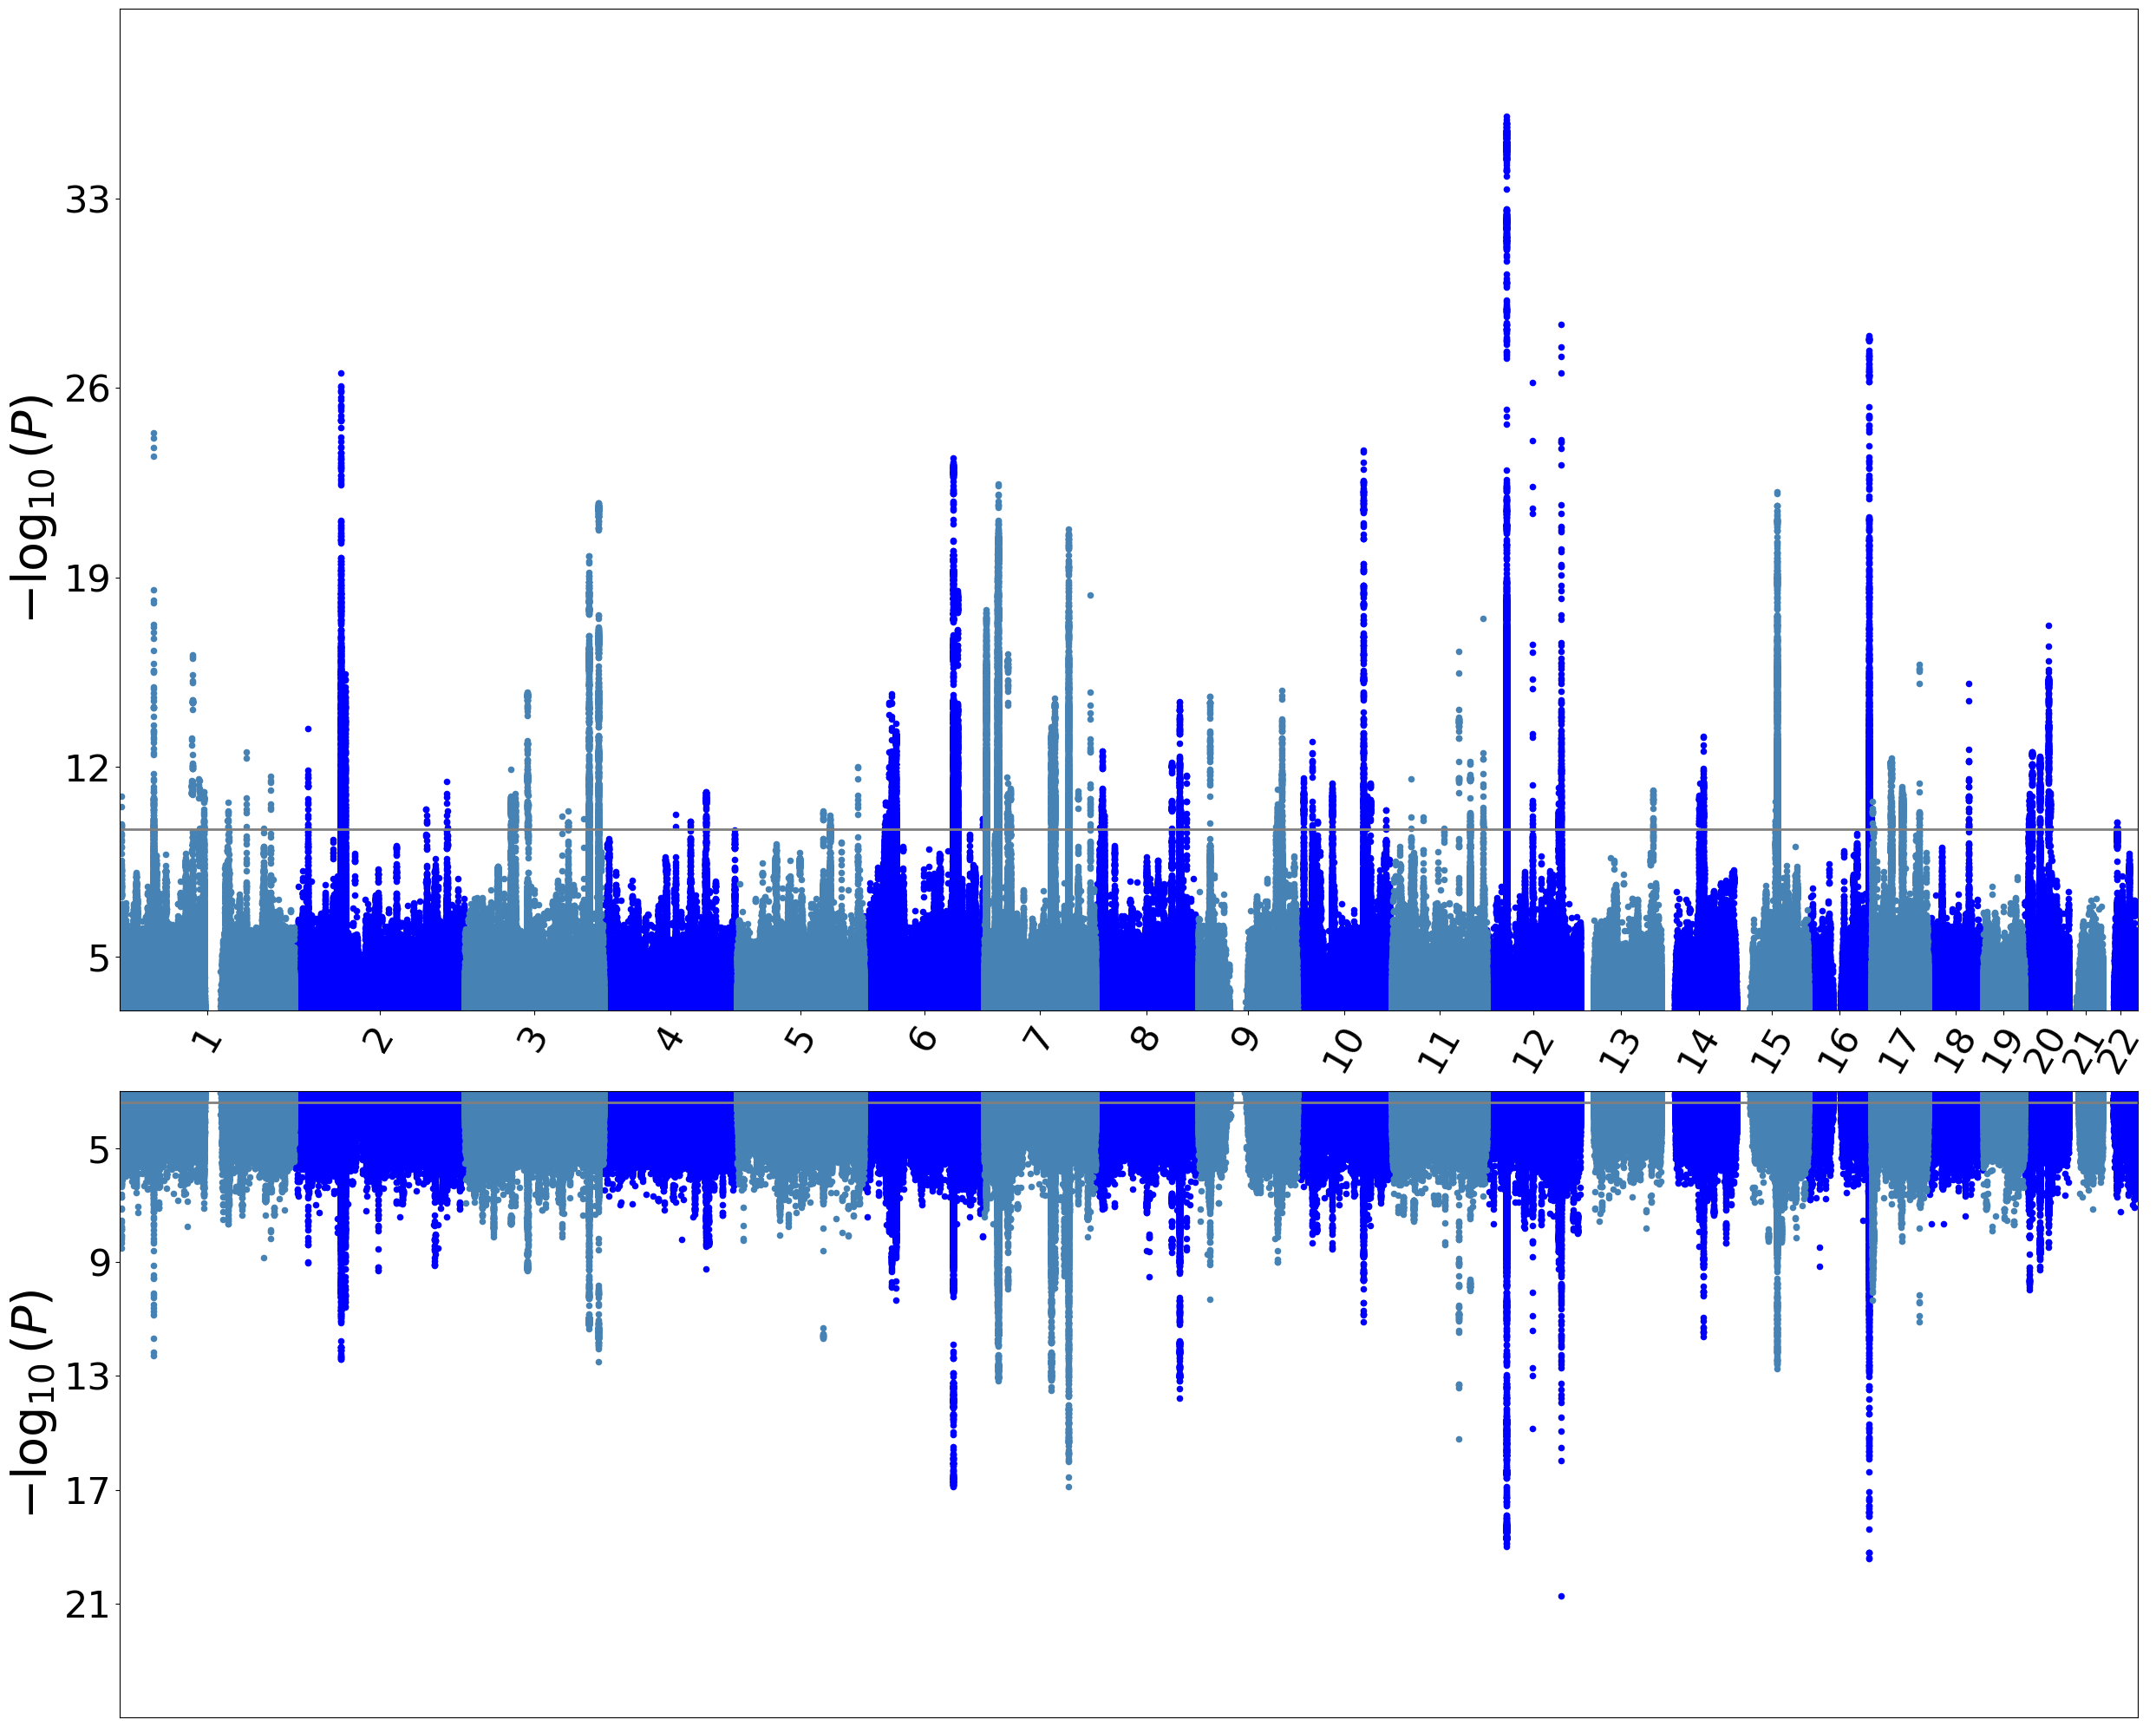

In [51]:
_ = plotm_loci(drawable, drawable_r, significance=[-np.log10(5e-8/256), -np.log10(0.05/126)])

Following are the code for plotting single Manhattan plot and QQ plot:

In [ ]:
from matplotlib import pyplot as plt
import numpy as np


def plotm(df, significance=-np.log10(5e-8), invy=False, xticks=True, save_path=None, title=None):
    global coord, coord_middle
    if coord is None:
        coord = np.cumsum(np.insert(df.groupby('CHR')['POS'].max().values, 0, 0)).astype('int64')
        coord_middle = (coord[:-1] + coord[1:])/2
    df = df[df.P < 1e-3].copy()
    df["COORDINATE"] = df.apply(lambda x: x.POS + coord[x.CHR-1], axis=1)
    df_even = df[df.CHR % 2 == 0]
    df_odd = df[df.CHR % 2 == 1]
    plt.figure(figsize=(25, 10))
    plt.scatter(df_even.COORDINATE, -np.log10(df_even.P), c='#0000ff', s=20)
    plt.scatter(df_odd.COORDINATE, -np.log10(df_odd.P), c='#4682b4', s=20)
    # plt.axhline(y=significance, color='gray', linestyle='-', linewidth = 2)
    plt.axhline(y=significance, color='gray', linestyle='-', linewidth = 2)
    ax = plt.gca()
    # ax.set_yscale('log')
    top = np.ceil(-np.log10(df.P[df.P != 0].min())/10)*10
    print(top)
    plt.ylim(bottom=3, top=top)
    plt.xlim([0, max(df_even.COORDINATE)])
    #ax.set_yticks([3, 10, 30, 100, 300])
    #ax.set_yticklabels(['3', '10', '30', '100', '300'], fontsize=31)
    ticks = list(range(5, int(top), int((top-5)//5)))
    ax.set_yticks(ticks)
    ax.set_yticklabels(list(map(str, ticks)), fontsize=31)
    if xticks is False:
        ax.set_xticks([])
    else:
        ax.set_xticks(coord_middle)
        ax.set_xticklabels(list(map(str, range(1, 23))), fontsize=31, rotation=60)
        # ax.set_xlabel('Chromosome', fontsize=40)
    if invy:
        ax.invert_yaxis()
    ax.set_ylabel('$-\log_{10}(P)$', fontsize=40)
    if title:
        plt.title(title, fontsize=40)
    if save_path:
        plt.savefig(save_path, quality=100)
    return plt.gcf()


def qq_plot(p, figsize=(20, 15), markersize=10, fontsize=40, save_path=None, title=None):
    plt.figure(figsize=figsize)
    n = len(p)
    plt.plot(-np.log10(np.linspace(1/n, 1, n)), -np.log10(sorted(p)), '.', markersize=markersize)
    plt.plot(np.array([0, -np.log10(1/n)]), np.array([0, -np.log10(1/n)]))
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.xlabel('expected p-value in -log10 scale', fontsize=fontsize)
    plt.ylabel('observed p-value in -log10 scale', fontsize=fontsize)
    if title:
        plt.title(title, fontsize=fontsize)
    if save_path:
        plt.savefig(save_path, quality=100)
    return plt.gcf()

### Heritability and genetic correlation



We use [ldsc](https://github.com/bulik/ldsc) to estimate the heritability and genetic correlation, here is the [documentation](https://github.com/bulik/ldsc/wiki/Heritability-and-Genetic-Correlation). The first step required by ldsc is to process the summary statistics as follows:
```Python
import os, re
from multiprocessing import Pool


cmd_munge = "/data4012/zxie3/anaconda3/envs/ldsc/bin/python /data4012/zxie3/ldsc/munge_sumstats.py --sumstats {} --N 22880 --out {} --a1 A1 --a2 A2 --p P --frq AF1 --out {}"
def munge(x):
    xname = x.split('/')[-1]
    os.system(cmd_munge.format(x, '/data4012/zxie3/AE_revision2/sumstats/ldsc_munged/'+xname))
with Pool(50) as p:
    p.map(munge, glob("/data4012/zxie3/AE_revision2/sumstats/*.fastGWA"))
```
Then heritability is estimated by calling ldsc:
```Python
# download european ldscore from https://ibg.colorado.edu/cdrom2019/nivard/genomicSEM/practical_1/eur_w_ld_chr/
cmd_h2 = "/data4012/zxie3/anaconda3/envs/ldsc/bin/python /data4012/zxie3/ldsc/ldsc.py --h2 {} --ref-ld-chr /data4012/zxie3/1000G_ldscore/ --w-ld-chr /data4012/zxie3/1000G_ldscore/ --out {}"

def h2(x):
    xname = x.split('/')[-1].split('.')[0]
    os.system(cmd_h2.format(x, f'/data4012/zxie3/AE_revision2/heritability/{xname}'))

with Pool(50) as p:
    p.map(h2, glob("/data4012/zxie3/AE_revision2/sumstats/ldsc_munged/*.gz"))

def parse_ldsc_h2_log(f):
    with open(f, 'r') as g:
        s = g.read()
    lines = s.strip().split('\n')
    h2, h2se = map(float, re.match(".*: (.+) \((.+)\)", lines[-7]).groups())
    lambda_GC = float(re.match(".*: (.+)", lines[-6]).group(1))
    intercept, intercept_se = map(float, re.match(".*: (.+) \((.+)\)", lines[-4]).groups())
    return f, h2, h2se, lambda_GC, intercept, intercept_se
                                                  
with Pool(50) as p:
    result = p.map(parse_ldsc_h2_log, glob("/data4012/zxie3/AE_revision2/heritability/*"))
                                                  
ldsc_out = pd.DataFrame.from_records(result, columns=['dim', 'h2', 'h2_se', 'lambda_GC', 'intercept', 'intercept_se'])
ldsc_out['dim'] = ldsc_out.dim.apply(lambda x: '_'.join(x.split('/')[1].split('_')[0:3:2]))
ldsc_out['modality'] = ldsc_out.dim.apply(lambda x: x.split('_')[0])
ldsc_out['dim'] = ldsc_out.dim.apply(lambda x: x.split('_')[1][2:])
ldsc_out.to_csv('/data4012/zxie3/AE_revision2/model128_ldsc_out.tsv', sep='\t', index=False)
```
Similarly we can also calculate the genetic correlation this way:
```Python
gc_cmd = "/data4012/zxie3/anaconda3/envs/ldsc/bin/python /data4012/zxie3/ldsc/ldsc.py --rg {},{} --ref-ld-chr /data4012/zxie3/1000G_ldscore/ --w-ld-chr /data4012/zxie3/1000G_ldscore/ --out {}"
pgc = combinations(glob("/data4012/zxie3/AE_revision2/sumstats/ldsc_munged/*.gz"), 2)

def pgc_job(x):
    f0 = x[0]
    f1 = x[1]
    fname0 = '_'.join(f0.split('/')[-1].split('_')[0:3:2])
    fname1 = '_'.join(f1.split('/')[-1].split('_')[0:3:2])
    os.system(gc_cmd.format(f0, f1, f"/data4012/zxie3/AE_revision2/pairwise_genetic_correlation/{fname0}~{fname1}"))

with Pool(250) as p:
    p.map(pgc_job, pgc)
```

### create minP file

We will use [FUMA](https://fuma.ctglab.nl/) to analyze our finding, you can also check [this paper](https://www.nature.com/articles/s41467-017-01261-5) for details. We will extract the minimum p value of each variants from all summary statistics and upload the minP file to FUMA.
We use the following code to create the minP file:

In [67]:
from pathlib import Path
import os, numpy as np
from tqdm import tqdm
from multiprocessing import Pool
from subprocess import check_output, STDOUT
from itertools import zip_longest
from glob import glob




def extract(x, exclusion, out_path):
    # extract rows in the file x not contained in exclusion and save in out_path.
    x = Path(x)
    out_path = Path(out_path)
    cmd = f"awk 'NR == FNR {{ excl[$1]; next }} !(FNR in excl)' {exclusion} {x} > {x.parent/out_path/(x.name.split('.')[0] + '_extracted')}"
    os.system(cmd)
    

def extract_col(x, offset=0):
    out = check_output(f"awk '{{print $(NF-{offset})}}' {x}", universal_newlines=True, shell=True, stderr=STDOUT)
    return np.array(list(map(float, out.strip('\n').split('\n')[1:]))), x

def create_minP(glob_list, pcol=0, mode='min'):
    # pcol is indexed from right to left, 0 means last col
    if mode == 'min':
        op = np.argmin
    elif mode == 'max':
        op = np.argmax
    else:
        raise Exception('not implemented')
    batch = 50
    for i in tqdm(range(0, len(glob_list), batch)):
        with Pool(batch) as q:
            result = q.starmap(extract_col, zip_longest(glob_list[i:i+batch], (), fillvalue=pcol))
        pnew, fnew = list(zip(*result))
        if i == 0:
            pnew = np.vstack(pnew)
            idx = op(pnew, 0)
            f = np.array(fnew)[idx]
        else:
            pnew = list(pnew)
            pnew.append(p)
            pnew = np.vstack(pnew)
            idx = op(pnew, 0)
            mask = (idx != (pnew.shape[0]-1))
            f[mask] = np.array(fnew)[idx[mask]]
        p = pnew[idx, np.arange(pnew.shape[1])]
    return p, f

With this, you can get the minimum p value of each SNP from all the summary statistis files.

In [71]:
p, f = create_minP(glob("/data4012/zxie3/AE_revision2/sumstats/T2*_discovery.fastGWA"), 1)

100%|██████████| 3/3 [05:21<00:00, 107.20s/it]


In [81]:
template = pd.read_table(f[0])

In [82]:
template["P"] = p
template[['CHR', 'SNP', 'POS', 'A1', 'A2', 'AF1', 'N', 'P']].to_csv("/data4012/zxie3/AE_revision2/minP/T2_model_128minP.tsv", sep='\t', index=False)

### Upload to FUMA

If you don't have an account, register [here](https://fuma.ctglab.nl/register). Then go to [here](https://fuma.ctglab.nl/snp2gene) to upload the minP file. It is possible to create a JS template to run in browser to fill in the text boxes but since it is just one file there is not too much gain. Once submitted, the job will be in a queue and normally it shouldn't take too long to finish then you can download the result. The previous FUMA results are at `/data4012/zxie3/AE_revision2/minP`.

### Loci clumping

Loci clumping is done by FUMA, but here we include the legacy code of loci clumping just using 250 kb threshold.

```Python
def snp_cluster(sorted_df):
    df = sorted_df.copy()
    delimit = (np.diff(df.CHR.values) != 0) | (np.diff(df.BP.values) > 250000)
    delimit = np.insert(delimit, 0, 0)
    df['LOCUS'] = np.cumsum(delimit)
    return df
```

### Loci overlap between multiple GWAS
After downloading the results from FUMA (SNP2GENE -> My Jobs -> Go to results -> Download -> Select All -> Download files), we can get loci information from the file `GenomicRiskLoci.txt`.
When comparing multiple GWAS results, we can see how the discovered loci overlap with each other.
We use the following code to find the overlap of the loci and draw the Venn diagram (matplotlib_venn only supports Venn diagram of 2 or 3 sets, if you want to draw Venn diagram of more sets, use `pyvenn`):


In [68]:
from intervaltree import IntervalTree, Interval
from matplotlib_venn import venn3, venn2
from matplotlib import pyplot as plt
import pandas as pd
from io import StringIO

def merge_interval(interval_set):
    start = min(map(lambda x: x.begin, interval_set))
    end = max(map(lambda x: x.end, interval_set))
    df = pd.concat(list(map(lambda x: pd.read_json(StringIO(x.data), orient='index').T, interval_set)), ignore_index=True)
    return Interval(start, end, df.to_json())

def build_loci_tree(df_list):
    trees = [IntervalTree() for _ in range(22)]
    for df in df_list:
        for _, row in df.iterrows():
            chrom = row.chr
            tree = trees[chrom-1]
            i = Interval(row.start-125000, row.end+125001, row.to_json()) # If the gap is less than 250k, merge the 2 interval
            o = tree.overlap(row.start-125000, row.end+125001)
            o.add(i)
            n = merge_interval(o)
            tree.remove_overlap(n.begin, n.end)
            tree.add(n)
    return trees


def venn_plot(trees, sources):
    assert len(sources) == 2 or len(sources) == 3, f"venn diagram plot only support 2 or 3 sets, got {len(sources)}"
    sets = [set() for _ in sources]
    for k, tree in enumerate(trees):
        for i, interval in enumerate(tree):
            df = pd.read_json(StringIO(interval.data), orient='index').T
            for j, s in enumerate(sources):
                if (df.SOURCE == s).sum() > 0:
                    sets[j].add((k, i))
    if len(sources) == 2:
        venn2(sets, sources)
    else:
        venn3(sets, sources)

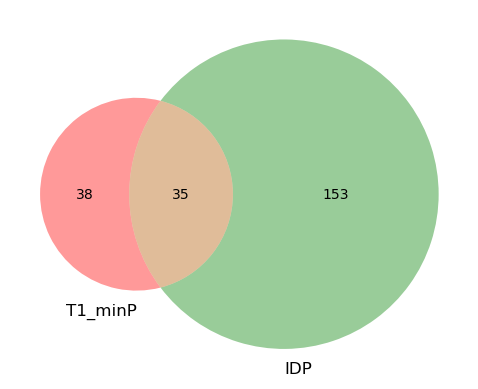

In [67]:
# this is an example of using the above code to draw the venn diagram of loci from 2 GWAS.
df1 = pd.read_table("/data4012/sislam3/playyard/MRI_UKB/POST_GWAS/data/AE/Revision2/minP/T1_model_128minP/GenomicRiskLoci.txt")
df2 = pd.read_table("/data4012/sislam3/playyard/MRI_UKB/POST_GWAS/data/AE/Revision2/minP/IDP_Thres_1437/GenomicRiskLoci.txt")
df1['SOURCE'] = 'T1_minP'
df2['SOURCE'] = "IDP"
trees = build_loci_tree([df1, df2])
venn_plot(trees, ['T1_minP', 'IDP'])
plt.gcf().subplots_adjust(left=0.1)

### Meta-analysis

After doing GWAS on discovery and replication cohort, we can use meta-analysis to pool the result together to increase the statistical power. Here is the reference script:
```Python
from glob import glob
from multiprocessing import Pool
import os

discovery_N = 22880
T1_replication_N = 12359
T2_replication_N = 11308
metal_path = "/data4012/zxie3/metal/metal"
metal_script = \
"""SEPARATOR TAB
SCHEME STDERR
MARKER SNP
WEIGHT DONTUSE
DEFAULTWEIGHT {}
ALLELE A1 A2
PVAL P
EFFECT BETA
STDERR SE
PROCESS {}
SEPARATOR  TAB
MARKER SNP
WEIGHT DONTUSE
DEFAULTWEIGHT {}
ALLELE A1 A2
PVAL P
EFFECT BETA
STDERR SE
PROCESS {}
OUTFILE {} .tbl
ANALYZE
QUIT
"""

def meta_job(x1, x2):
    fname = x1.split('/')[-1]
    modality, model, dim = fname.split('_')[:3]
    if modality == "T1":
        replN = T1_replication_N
    else:
        replN = T2_replication_N
    metal_script_path = f'meta/{modality}_{model}_{dim}_metal_script'
    with open(metal_script_path, 'w') as f:
        f.write(metal_script.format(discovery_N, x1, replN, x2, f'meta/{modality}_{model}_{dim}')) # change the path to your destination
    os.system(f"{metal_path} {metal_script_path}")

T1_disc = sorted(glob("/data4012/zxie3/AE_revision2/sumstats/T1_model128_QT*discovery*.fastGWA"))
T1_repl = sorted(glob("/data4012/zxie3/AE_revision2/sumstats/T1_model128_QT*replication*.fastGWA"))
# actual running of the job
with Pool(10) as p:
    p.starmap(meta_job, zip(T1_disc, T1_repl))
```
You can run the following command to see the result of meta-analysis, note that there are some multi-allelic sites that will cause warning from metal, it is possible to filter them afterward, by detecting "?" in the effect direction.
```Python
import pandas as pd


with open('metal_script_test', 'w') as f:
    f.write(metal_script.format(discovery_N, T1_disc[0], T1_replication_N, T1_repl[0], 'test'))
os.system(f"{metal_path} metal_script_test")
tb = pd.read_table("test1.tbl")
```

### Upload to GWAS Catalog

Here is the script for formatting the summary statistics to conform with GWAS Catalog requirements and generating the description table, you then need to use the [globus client](https://www.globus.org/globus-connect-personal) to upload the summary statistics to the network folder designated by GWAS Catalog team:
```Python
# https://www.ebi.ac.uk/gwas/docs/submission
# https://www.ebi.ac.uk/gwas/docs/summary-statistics-format#validator
# https://www.ebi.ac.uk/gwas/deposition
import pandas as pd, os
from glob import glob
from gwas_sumstats_tools.validate import validate
from multiprocessing import Pool
from tqdm import tqdm
from openpyxl import load_workbook


validator_path = "/data4012/zxie3/anaconda3/envs/workflow/lib/python3.9/site-packages/gwas_sumstats_tools/validate.py"
files = glob("/data4012/zxie3/AE_revision2/sumstats/*model128*.fastGWA")
columns = ["chromosome", "base_pair_location", "effect_allele", "other_allele", "beta", "standard_error", "effect_allele_frequency", "p_value"]
mapping = {"CHR":"chromosome", "POS":"base_pair_location", "A1":"effect_allele", "A2":"other_allele", "BETA":"beta", "SE":"standard_error", "AF1":"effect_allele_frequency", "P":"p_value"}

def parse_name(x):
    modality, model, qt, cohort = x.split('/')[-1].split('_')
    cohort = cohort.split('.')[0]
    return f"{modality}_{qt}_{cohort}"

def proc(x, path):
    df = pd.read_table(x)
    df.rename(columns=mapping)[columns].to_csv(path, sep='\t', index=False)

with Pool(5) as p:
    p.starmap(proc, tqdm.tqdm(zip(files[1:], map(lambda x: f"/data4012/zxie3/AE_revision2/gwascatalog_submission/{parse_name(x)}.tsv", files[1:]))))
# validate(f"/data4012/zxie3/AE_revision2/gwascatalog_submission/{parse_name(files[0])}.tsv")
# https://www.ebi.ac.uk/gwas/docs/submission-summary-statistics-plus-metadata
os.system("md5sum /data4012/zxie3/AE_revision2/gwascatalog_submission/*.tsv > /data4012/zxie3/AE_revision2/checksum")
md5_df = pd.read_table("/data4012/zxie3/AE_revision2/checksum", header=None, sep='\s+')
Study_tag = "MRI_AE_GWAS_MODEL128_{}_QT{}_{}" #A5 modality T1/T2, dimension and discovery/replication
Genotyping_technology = "Genome-wide genotyping array" #B5
Array_manufacturer = "Affymetrix" #C5
Analysis_software = "GCTA fastGWA" #E5
Imputation = "Yes" #F5
Reported_trait = "Algorithmically Discovered Brain Morphology-Related Trait" #M5
Summary_statistics_file  = "{}_QT{}_{}.tsv" #O5 modality T1/T2, dimension and discovery/replication
md5_sum = "" #P5 md5
citation = 'Patel, Khush, et al. "New phenotype discovery method by unsupervised deep representation learning empowers genetic association studies of brain imaging." medRxiv (2022): 2022-12.'
Readme = citation #Q5
Summary_statistics_assembly = "GRCh37"  #R5
Coordinate_system = "1-based"  #Z5
Stage = "discovery" # discovery/replication
Ancestry_category = "European"
Ancestry = "British White"
Country_of_recruitment = "U.K."
Variant_count_dict = {("T1", "discovery"): 8925988, ("T1", "replication"): 8925870, ("T2", "discovery"):8925988, ("T2", "replication"): 8925814}
Number_of_individuals_dict = {("T1", "discovery"): 22960, ("T1", "replication"): 12405, ("T2", "discovery"):22960, ("T2", "replication"): 11265}
workbook = load_workbook('/data4012/zxie3/AE_revision2/new_template.xlsx')
study  = workbook['study']
sample = workbook['sample']
# modality = 'T1'
# dim = 0
# cohort = "discovery"
line = 5  # start from 5th line in the excel sheet
for modality in ["T1", "T2"]:
    for cohort in ["discovery", "replication"]:
        for dim in range(128):
            summary_statistics_file = Summary_statistics_file.format(modality, dim, cohort)
            if not os.path.exists(f"gwascatalog_submission/{summary_statistics_file}"):
                print(summary_statistics_file)
                continue
            study_tag = Study_tag.format(modality, dim, cohort)
            variant_count = Variant_count_dict[(modality, cohort)]

            md5 = md5_df[md5_df[1] == f"gwascatalog_submission/{summary_statistics_file}"][0].values[0]
            stage = cohort
            number_of_individuals = Number_of_individuals_dict[(modality, cohort)]
            study_filling = [study_tag, Genotyping_technology, Array_manufacturer, Analysis_software, Imputation, variant_count,
                             Reported_trait, summary_statistics_file, md5, Readme, Summary_statistics_assembly, Coordinate_system]
            study_filling_cell = [f'{x}{line}' for x in ['A', 'B', 'C', 'E', 'F', 'I', 'M', 'O', 'P', 'Q', 'R', 'Z']]
            for (cell, content) in zip(study_filling_cell, study_filling):
                study[cell] = content
            sample_filling = [study_tag, stage, number_of_individuals, Ancestry_category, Ancestry, Country_of_recruitment]
            sample_filling_cell = [f'{x}{line}' for x in ['A', 'B', 'C', 'H', 'I', 'L']]
            for (cell, content) in zip(sample_filling_cell, sample_filling):
                sample[cell] = content
            line += 1
workbook.save(f'/data4012/zxie3/AE_revision2/GWASCatalog_submission_form/all.xlsx')
```

### Gene list interpretation

Here is an example of using langchain to query the pubmed for gene interpretation:

In [166]:
from dotenv import load_dotenv
from langchain_openai import AzureChatOpenAI
import google.generativeai as genai
from langchain.retrievers import PubMedRetriever
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables.base import Runnable
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langchain.output_parsers import ResponseSchema, StructuredOutputParser
from langchain_core.runnables import RunnableLambda
from langchain.chains import LLMChain
from typing import List, Optional
from IPython.display import display, Markdown
# from langchain.callbacks import get_openai_callback
import os
load_dotenv()

True

In [125]:
# go to https://ai.google.dev/ to get the api key
genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))

In [343]:
class Model(Runnable):
    def __init__(self):
        self.model = model = genai.GenerativeModel('gemini-pro', generation_config=genai.GenerationConfig(temperature=0))
    def invoke(self, query, *args, **kwargs):
        if not isinstance(query, str):
            query = query.text
        return self.model.generate_content(query).parts[0].text

In [344]:
model = Model()

In [357]:
import urllib, time

class Retriever(PubMedRetriever):
    keyword: str = "brain"
    outputs: Optional[List[Document]] = None
    def __init__(self, keyword: str="brain", **kwargs):
        super().__init__(**kwargs)
        self.sleep_time = 0.34
        self.base_url_esearch = self.base_url_esearch + "sort=relevance&"
        self.keyword = keyword
    
    def invoke(self, gene, *args, **kwargs):
        query = gene + " " + self.keyword
        result = self.load(query)
        self.outputs = result
        return {"docs": result, "gene": gene}
    
    def retrieve_article(self, uid: str, webenv: str) -> dict:
        url = (
            self.base_url_efetch
            + "db=pubmed&retmode=xml&id="
            + uid
            + "&webenv="
            + webenv
        )

        retry = 0
        while True:
            try:
                result = urllib.request.urlopen(url)
                break
            except urllib.error.HTTPError as e:
                if e.code == 429 and retry < self.max_retry:
                    # Too Many Requests errors
                    # wait for an exponentially increasing amount of time
                    print(  # noqa: T201
                        f"Too Many Requests, "
                        f"waiting for {self.sleep_time:.2f} seconds..."
                    )
                    time.sleep(self.sleep_time)
                    retry += 1
                else:
                    raise e

        xml_text = result.read().decode("utf-8")
        text_dict = self.parse(xml_text)
        return self._parse_article(uid, text_dict)

In [358]:
k = 5
retriever = Retriever(top_k_results=k)

In [359]:
# from multiprocessing import Pool


# model = AzureChatOpenAI(azure_deployment="test", temperature=0)
def job(doc, gene):
    r = map_chain.invoke({"context":str(doc), "gene":result["gene"]})
    return r["text"]

@RunnableLambda
def mapper(result):
    prompt = PromptTemplate.from_template(
        "validate that the following document talks about the relation between the gene {gene} and the brain, "+\
        "give the output in markdown format, first display the title of the article, " +\
        "followed by a short reasoning on why this is not relevant if this article is not relevant, "+\
        "otherwise give a short summarization if it is relevant to the gene {gene} and the brain, " + \
        "\n{context}"
    )
    map_chain = LLMChain(llm=model, prompt=prompt)
    return {"context": "\n".join(map_chain.invoke({"context":str(doc), "gene":result["gene"]})["text"] for doc in result["docs"]),
            "gene": result["gene"]}
    """
    with Pool(len(result)) as p:    
        r = p.starmap(job, zip(result["docs"], [result["gene"]]*len(result["docs"])))
    return {"context": "\n".join(r), "gene": result["gene"]}
    """

In [360]:
reduce_prompt = PromptTemplate.from_template(
    "Check each summary carefully, exclude summaries that don't make sense, give an overview on the relationship between {gene} and the brain based on the remaining summaries, " +\
    "Insert the article index whenever you mentioned the result from an article, using [index], then include the title of these articles at the end as a json output enclosed in bracket {{}}, the key should be the index of the article, only use one bracket.\nHere are the context:\n{context}"
)
reducer = LLMChain(llm=model, prompt=reduce_prompt)

In [361]:
chain = retriever|mapper|reducer

In [362]:
final_output = chain.invoke("STIL")

Too Many Requests, waiting for 0.34 seconds...


In [363]:
def similarity(a, b):
    set_a = set(a.strip().split(' '))
    set_b = set(b.strip().split(' '))
    return len(set_a.intersection(set_b))/len(set_a.union(set_b))


def verification(final_output, retriever):
    start = final_output['text'].find("{")
    end = final_output['text'].find("}") + 1 
    titles = list(eval(final_output['text'][start:end]).values())
    
    def extract_title(x):
        title = x["Title"]
        return title if isinstance(title, str) else title['#text']
    
    original_titles = list(map(lambda x: extract_title(x), retriever.outputs))
    cnt = 0
    for t in titles:
        if any([similarity(t, tp) > 0.7 for tp in original_titles]):
            cnt += 1
        else:
            print(f"'{t}' not in original retrieved results")
    return True if cnt > 0 else False

In [364]:
verification(final_output, retriever)

True

In [365]:
display(Markdown(final_output["text"]))

**Summaries that make sense:**

* **[1]** This article is relevant to the gene STIL and the brain because it discusses the role of STIL in the control of centriole duplication and mitotic spindle integrity, and how pathological perturbations of its finely tuned expression result in chromosomal instability in both embryonic and postnatal situations.
* **[2]** This article is relevant to the gene STIL and the brain because it discusses a new gene that has been identified as a cause of microcephaly, a condition characterized by an abnormally small head and brain. The article provides evidence that mutations in the STIL gene can lead to microcephaly in humans and mice, and it discusses the potential role of STIL in brain development.
* **[3]** This article is relevant to the gene STIL and the brain because it describes a mutation in the STIL gene that causes a rare brain malformation called lobar holoprosencephaly. This malformation is characterized by a failure of the brain to divide into two hemispheres, resulting in a single, undivided brain. The article also describes how this mutation causes microcephaly, which is a condition characterized by an abnormally small head.
* **[4]** This article is relevant to the gene STIL and the brain because it describes a homozygous mutation in the STIL gene that causes holoprosencephaly and microcephaly in two siblings. Holoprosencephaly is a congenital malformation of the brain characterized by impaired forebrain cleavage and midline facial anomalies. Microcephaly is a condition characterized by an abnormally small head. The STIL gene has a role in centriole formation, and mutations in this gene have been previously described in rare cases of microcephaly. The findings in this article suggest that homozygous mutations in the STIL gene can cause a recessive form of holoprosencephaly and microcephaly.

**Overview of the relationship between STIL and the brain:**

The STIL gene plays a crucial role in brain development and function. Mutations in the STIL gene can lead to a variety of brain malformations, including microcephaly, holoprosencephaly, and dopaminergic neuron dysfunction. These findings suggest that STIL is a key regulator of brain development and function, and that mutations in this gene can have devastating consequences.

{
  "1": "STIL balancing primary microcephaly and cancer.",
  "2": "STIL on my small brain: a new gene for microcephaly.",
  "3": "STIL mutation causes autosomal recessive microcephalic lobar holoprosencephaly.",
  "4": "Homozygous STIL mutation causes holoprosencephaly and microcephaly in two siblings."
}

In [349]:
display(Markdown(final_output["text"]))

Based on the remaining summaries, the relationship between STIL and the brain can be summarized as follows:

STIL is a centriolar protein that plays a role in cell cycle and chromosomal segregation. Deregulation of the STIL gene expression can lead to insufficient brain development (primary microcephaly) or cancer [1]. Additionally, STIL has been implicated in the development of holoprosencephaly (HPE) and microcephaly, both of which are congenital brain malformations [4]. The involvement of STIL in brain development is supported by its role in centriole formation and its expression during early patterning of the forebrain [4]. Furthermore, STIL has been identified as a multi-function protein required for dopaminergic neural proliferation, protection, and regeneration, which are relevant to Parkinson's disease [5].

Therefore, the relationship between STIL and the brain is that STIL is involved in brain development, particularly in processes related to cell cycle, chromosomal segregation, and neural proliferation, protection, and regeneration.

The articles mentioned in the summaries are:
{1: "STIL balancing primary microcephaly and cancer"}
{4: "Homozygous STIL mutation causes holoprosencephaly and microcephaly in two siblings"}
{5: "STIL: a multi-function protein required for dopaminergic neural proliferation, protection, and regeneration"}

In [366]:
retriever.outputs

[{'uid': '29352115',
  'Title': 'STIL balancing primary microcephaly and cancer.',
  'Published': '2018-01-19',
  'Copyright Information': '',
  'Summary': 'Cell division and differentiation are two fundamental physiological processes that need to be tightly balanced to achieve harmonious development of an organ or a tissue without jeopardizing its homeostasis. The role played by the centriolar protein STIL is highly illustrative of this balance at different stages of life as deregulation of the human STIL gene expression has been associated with either insufficient brain development (primary microcephaly) or cancer, two conditions resulting from perturbations in cell cycle and chromosomal segregation. This review describes the recent advances on STIL functions in the control of centriole duplication and mitotic spindle integrity, and discusses how pathological perturbations of its finely tuned expression result in chromosomal instability in both embryonic and postnatal situations, hig